<a href="https://colab.research.google.com/github/Samraat-22/first-project/blob/main/cat_dog_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:

from google.colab import files
uploaded = files.upload()

import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


data = pd.read_csv("file.csv")
# space hatako
data.columns = data.columns.str.strip()

print("Columns:", data.columns)
print(data.head())

# Model train garda null value हुन मिल्दैन Data continuous banauxa  trivayera missing value lai previous ley fill garaye
data.fillna(method='ffill', inplace=True)


if 'Date/Time' in data.columns:
    data['Date/Time'] = pd.to_datetime(data['Date/Time'], errors='coerce')
    data['Month'] = data['Date/Time'].dt.month
    data['Day'] = data['Date/Time'].dt.day
    data.drop(columns=['Date/Time'], inplace=True)

target = 'Temp_C'
X = data.drop(columns=[target], errors='ignore')
X = X.select_dtypes(include=['number'])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Temp")
plt.ylabel("Predicted Temp")
plt.show()


TypeError: 'NoneType' object is not subscriptable

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers,models

In [ ]:
base_model=VGG16(weights='imagenet',include_top=False,input_shape=(224,224,3))

In [ ]:
# freeze base model trainig fast over fiiting ma kam lagxa

for layer in base_model.layers:
  layer.trainable=False


inputs = tf.keras.layers.Input(shape=(224, 224, 3)) #224x224 pixels, 3 channel (RGB).
# mage pahila VGG16 ma janxa.
#  training=False → BatchNorm/Dropout stable hunxa.
x = base_model(inputs, training=False)
# 1D ector ma conver garxa
x = tf.keras.layers.Flatten()(x)
# RElu vaneko fast training method  custom learning layer
x = tf.keras.layers.Dense(128, activation='relu')(x)
# softmax gies probality
outputs = tf.keras.layers.Dense(3, activation='softmax')(x)

model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
#  Adam → automatic learning rate adjust.
#  categorical_crossentropy → multi-class label ko lagi.
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("VGG16 Model Ready ")

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(224,224,3)),
    tf.keras.layers.Conv2D(32,(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
print("modelready")

In [ ]:
import os
os.environ['KAGGLE_USERNAME'] = 'samraatpaudel'
os.environ['KAGGLE_KEY'] = 'KGAT_9b23af6ce43b2b7f27348e7119fa35be'
print(" Kaggle auth done!")

In [ ]:
os.system('pip install kaggle -q')
os.system('kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset')
os.system('unzip -q microsoft-catsvsdogs-dataset.zip -d dataset')
print(" Dataset ready!")

In [ ]:
import os
cats = len(os.listdir('dataset/PetImages/Cat'))
dogs = len(os.listdir('dataset/PetImages/Dog'))
print(f" Cat images: {cats}")
print(f" Dog images: {dogs}")

In [ ]:
from PIL import Image
import os

removed = 0
for folder in ['Cat', 'Dog']:
    path = f'dataset/PetImages/{folder}'
    for fname in os.listdir(path):
        fpath = os.path.join(path, fname)
        try:
            img = Image.open(fpath)
            img.verify()
        except:
            os.remove(fpath)
            removed += 1

print(f" {removed}  ")

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    rotation_range=15
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    'dataset/PetImages',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_data = val_datagen.flow_from_directory(
    'dataset/PetImages',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    seed=42
)

print("Class indices:", train_data.class_indices)
print(f"Train batches: {len(train_data)}")
print(f"Val batches:   {len(val_data)}")

 Model ready!
Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
 Data ready!
Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 337s 535ms/step - accuracy: 0.8726 - loss: 0.3064 - val_accuracy: 0.9280 - val_loss: 0.1867
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 321s 513ms/step - accuracy: 0.9099 - loss: 0.2162 - val_accuracy: 0.9370 - val_loss: 0.1585
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 330s 528ms/step - accuracy: 0.9209 - loss: 0.1882 - val_accuracy: 0.9348 - val_loss: 0.1705
Training complete!


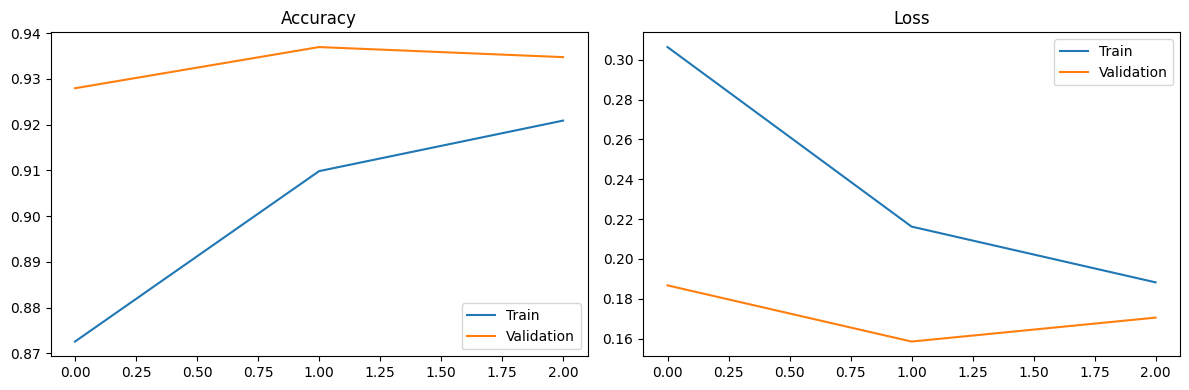

In [22]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 1. Model
base_model = tf.keras.applications.VGG16(
    weights='imagenet', include_top=False, input_shape=(224, 224, 3)
)
for layer in base_model.layers:
    layer.trainable = False

inputs  = tf.keras.layers.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = tf.keras.layers.Flatten()(x)
x       = tf.keras.layers.Dense(128, activation='relu')(x)
x       = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(2, activation='softmax')(x)
model   = tf.keras.models.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(" Model ready!")


train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2,
                                   horizontal_flip=True, zoom_range=0.2)
val_datagen   = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = train_datagen.flow_from_directory(
    'dataset/PetImages', target_size=(224,224),
    batch_size=32, class_mode='categorical', subset='training', seed=42)
val_data = val_datagen.flow_from_directory(
    'dataset/PetImages', target_size=(224,224),
    batch_size=32, class_mode='categorical', subset='validation', seed=42)
print(" Data ready!")


history = model.fit(
    train_data, validation_data=val_data, epochs=3,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
)
print("Training complete!")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.legend()
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.legend()
plt.tight_layout()
plt.show()

In [20]:
model.save('cat_dog_vgg16.h5')
print(" Model saved!")

✅ Model saved!


In [13]:
predict_image('dataset/PetImages/Cat/10.jpg')
predict_image('dataset/PetImages/Dog/10.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Cat  —  100.0% confident
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
 Dog  —  100.0% confident


In [23]:
model.save('cat_dog_vgg16.h5')
print(" Model saved!")

 Model saved!


In [24]:
model.save('cat_dog_vgg16.h5')
from google.colab import drive
drive.mount('/content/drive')
import shutil
shutil.copy('cat_dog_vgg16.h5', '/content/drive/MyDrive/cat_dog_vgg16.h5')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/cat_dog_vgg16.h5'